The No-Cloning Theorem

It states that you cannot make a perfect copy of an unknown quantum state.

If Alice has a qubit: ∣ψ⟩ = α∣0⟩ + β∣1⟩,
she cannot simply duplicate it and send the copy to Bob.

Because measuring the qubit destroys its delicate superposition information.

So teleportation solves this problem by destroying Alice’s original state &
reconstructing the exact same state on Bob’s qubit.

The state moves. The original does not survive.

That’s why it’s called teleportation instead of copying.

In [35]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [36]:
# 1 qbit for the msg, 1 qbit for Alice & 1 qbit for Bob.

qc = QuantumCircuit(3, 3) 

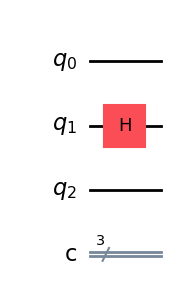

In [37]:
qc.h(1)
qc.draw("mpl")

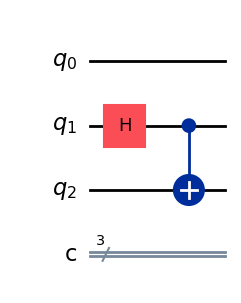

In [38]:
# Create entanglement --> Bell State.

qc.cx(1, 2) 
qc.draw("mpl")

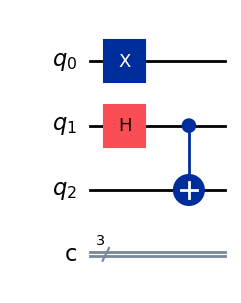

In [39]:
# Prepare message state

qc.x(0)

qc.draw("mpl")

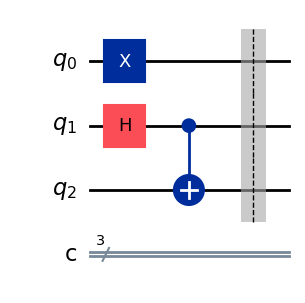

In [40]:
qc.barrier()

qc.draw("mpl")

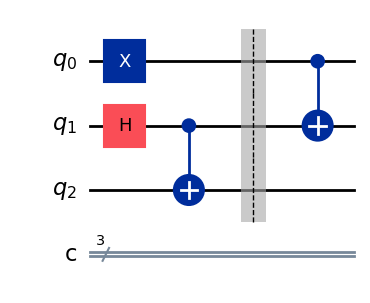

In [41]:
# Create entanglement with q0 & q1

qc.cx(0, 1) # CNOT 1st 'cause H|1> = |0> - |1> / sq.rt(2)

qc.draw("mpl")

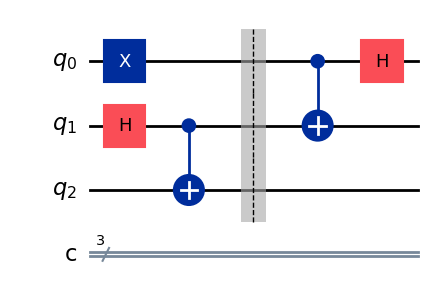

In [42]:
qc.h(0)

qc.draw("mpl")

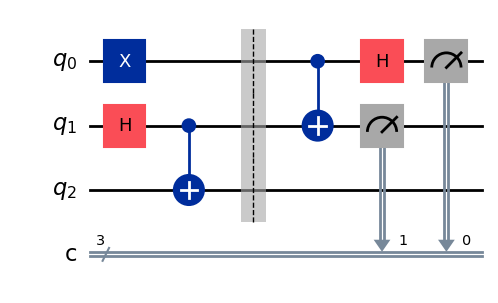

In [43]:
# Bell measurement.

qc.measure(0, 0) # 0 OR 1.

# At this point: Alice’s original state is destroyed, only classical bits remain on her side.

qc.measure(1, 1)

qc.draw("mpl")

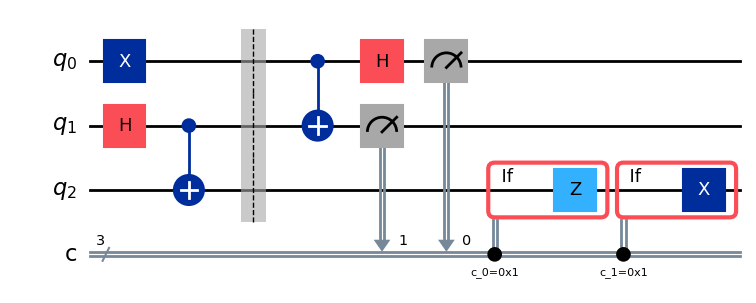

In [44]:
# Bob's correction gates

# If classical bit 0 equals 1: apply Z gate to q2.
# Z corrects phase errors introduced during teleportation: ∣1⟩ → −∣1⟩

with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)

# If classical bit 1 equals 1: apply X gate to q2.
# This is because certain Bell measurement outcomes flip Bob’s qubit incorrectly.
# X fixes that bit flip: |0> ↔ |1>

with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)

qc.draw("mpl")

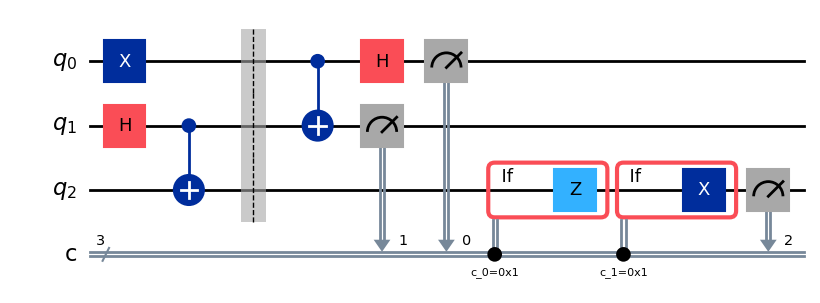

In [45]:
# Verification.

qc.measure(2, 2)

qc.draw("mpl")

In [46]:
# Prepare circuit for simulation.

simulator = AerSimulator()

result = simulator.run(qc).result()

In [47]:
counts = result.get_counts()

print(counts)

{'110': 242, '100': 278, '111': 241, '101': 263}


Remember the bit order in Qiskit counts is usually: c2c1c0

Focusing on the LEFTMOST bit (c2), which is Bob’s qubit; Bob always matches the initial states
we prepared using qc.x(0): ∣1⟩

So teleportation succeeded!

The other bits (c1, c0) vary because Alice’s Bell measurement outcomes are probabilistic. 

The correction logic compensates for those random outcomes so Bob still reconstructs the correct final state.